## clash 정보, plddt 정보 csv파일에 포함하기 

### 필요한 함수 

In [1]:
import numpy as np 
from Bio.PDB import PDBParser

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_file, cdr_type):
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]

    structure = parser.get_structure("structure", pdb_file)
    
    # 첫 번째 체인 추출
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []
    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":  # 표준 아미노산만 고려
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                # 각 원자의 B-factor 가져오기
                for atom in residue:
                    b_factors.append(atom.get_bfactor())

    return np.mean(b_factors)


### plddt 

In [ ]:
import pandas as pd
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from data.ab_metrics import renumber_pdb  # 또는 renumber_chain

###################################################################################################################
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-08_22-44-09/get_capri/capri_info.csv'
base_dir = Path('/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-08_22-44-09')
###################################################################################################################

cdr_list = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']
df = pd.read_csv(csv_file)

for cdr in cdr_list:
    df[f"{cdr}_plddt"] = None

# ---- 병렬 처리 함수 정의 ----
def process_row(row):
    import traceback
    from data.ab_metrics import renumber_pdb
    try:
        pdb_path = str(base_dir / row['pdb_id'] / row['data_name'] / row['sample_id'] / 'get_capri' / 'sample_1_rechain.pdb')
        output_path = str(base_dir / row['pdb_id'] / row['data_name'] / row['sample_id'] / 'get_capri' / 'sample_1_chothia.pdb')

        # 1️⃣ renumber
        _ = renumber_pdb(pdb_path, out_pdb_file=output_path)

        # 2️⃣ pLDDT 계산
        cdr_plddts = {}
        for cdr in cdr_list:
            cdr_plddts[cdr] = calculate_b_factor_mean(output_path, cdr)

        return (row.name, cdr_plddts, None)

    except Exception as e:
        return (row.name, None, str(e) + "\n" + traceback.format_exc())

# ---- 병렬 실행 ----
results = []
num_workers = min(8, os.cpu_count())  # 병렬 프로세스 수 제한
print(f"🧠 Using {num_workers} parallel workers")

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    futures = [executor.submit(process_row, row) for _, row in df.iterrows()]
    for i, f in enumerate(as_completed(futures), 1):
        idx, cdr_plddts, err = f.result()
        if err:
            print(f"❌ Error at index {idx}: {err}")
            continue
        for cdr in cdr_list:
            df.at[idx, f"{cdr}_plddt"] = cdr_plddts[cdr]
        if i % 10 == 0 or i == len(df):
            print(f"✅ Progress: {i}/{len(df)} done")

# ---- CSV 저장 ----
output_csv = csv_file.replace(".csv", "_with_plddt.csv")
df.to_csv(output_csv, index=False)
print(f"\n✅ Saved updated CSV to: {output_csv}")


### plddt 계산 (w/o dockq 계산)

In [5]:
import pandas as pd
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from data.ab_metrics import renumber_pdb_wt_constant
from experiments.utils import calculate_b_factor_mean

###################################################################################################################
base_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-09_16-59-39'
###################################################################################################################

cdr_list = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']
os.makedirs(os.path.join(base_dir, 'get_capri'), exist_ok=True)
csv_file = os.path.join(base_dir, 'get_capri', 'capri_info_with_plddt.csv')


def process_sample(args):
    """단일 샘플 처리 함수 (병렬 실행용)"""
    pdb_id, kkh_sample, sample, sample_path, output_path = args

    if not os.path.exists(sample_path):
        return None

    try:
        _ = renumber_pdb_wt_constant(sample_path, output_path)
    except Exception as e:
        print(f"[WARN] renumber_pdb_wt_constant failed for {sample_path}: {e}")
        return None

    cdr_plddts = {}
    for cdr in cdr_list:
        try:
            cdr_plddts[cdr] = calculate_b_factor_mean(output_path, cdr)
        except Exception as e:
            print(f"[WARN] Failed to calculate {cdr} for {output_path}: {e}")
            cdr_plddts[cdr] = None

    return {
        'pdb_id': pdb_id,
        'data_name': kkh_sample,
        'sample_id': sample,
        **{f'{cdr}_plddt': cdr_plddts[cdr] for cdr in cdr_list}
    }


# ================================================================================================================
# 1️⃣ 처리할 모든 샘플 경로를 미리 수집
# ================================================================================================================
tasks = []
for pdb_id in os.listdir(base_dir):
    if 'config' in pdb_id:
        continue
    pdb_dir = os.path.join(base_dir, pdb_id)

    for kkh_sample in os.listdir(pdb_dir):
        if 'capri' in kkh_sample:
            continue
        kkh_sample_dir = os.path.join(pdb_dir, kkh_sample)

        for sample in os.listdir(kkh_sample_dir):
            sample_path = os.path.join(kkh_sample_dir, sample, 'sample_1.pdb')
            output_path = os.path.join(kkh_sample_dir, sample, 'sample_1_chothia.pdb')
            tasks.append((pdb_id, kkh_sample, sample, sample_path, output_path))

print(f"[INFO] Total {len(tasks)} samples found. Starting multiprocessing...")

# ================================================================================================================
# 2️⃣ 멀티프로세싱 실행
# ================================================================================================================
records = []
max_workers = 20  # 모든 CPU 코어 사용
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(process_sample, task) for task in tasks]
    for i, future in enumerate(as_completed(futures), start=1):
        result = future.result()
        if result is not None:
            records.append(result)
        if i % 50 == 0:
            print(f"[INFO] Processed {i}/{len(futures)} samples")

# ================================================================================================================
# 3️⃣ 결과 CSV로 저장
# ================================================================================================================
df = pd.DataFrame(records, columns=['pdb_id', 'data_name', 'sample_id'] + [f'{cdr}_plddt' for cdr in cdr_list])
os.makedirs(os.path.dirname(csv_file), exist_ok=True)
df.to_csv(csv_file, index=False)
print(f"[INFO] CSV saved to {csv_file} ({len(df)} rows)")


chain_res [<Residue GLN het=  resseq=1 icode= >, <Residue VAL het=  resseq=2 icode= >, <Residue GLN het=  resseq=3 icode= >, <Residue LEU het=  resseq=4 icode= >, <Residue VAL het=  resseq=5 icode= >, <Residue GLN het=  resseq=6 icode= >, <Residue SER het=  resseq=7 icode= >, <Residue GLY het=  resseq=8 icode= >, <Residue ALA het=  resseq=9 icode= >, <Residue GLU het=  resseq=10 icode= >, <Residue VAL het=  resseq=11 icode= >, <Residue LYS het=  resseq=12 icode= >, <Residue LYS het=  resseq=13 icode= >, <Residue PRO het=  resseq=14 icode= >, <Residue GLY het=  resseq=15 icode= >, <Residue ALA het=  resseq=16 icode= >, <Residue SER het=  resseq=17 icode= >, <Residue VAL het=  resseq=18 icode= >, <Residue LYS het=  resseq=19 icode= >, <Residue VAL het=  resseq=20 icode= >, <Residue SER het=  resseq=21 icode= >, <Residue CYS het=  resseq=22 icode= >, <Residue LYS het=  resseq=23 icode= >, <Residue ALA het=  resseq=24 icode= >, <Residue SER het=  resseq=25 icode= >, <Residue GLY het=  ress

## rmsd 계산 

In [ ]:
from Bio import PDB
import numpy as np
import os
import pandas as pd 

########################################################################################################
kkh_dir = "/home/psh/protein-frame-flow/inference_outputs/kkh_20251020_chothia"
cdrflow_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/kkh'
plddt_csv = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/kkh/get_capri/capri_info_with_plddt_merged_with_kkh.csv'
########################################################################################################
csv_info = pd.read_csv(plddt_csv)

# -------------------------------
# Chothia numbering 기준 CDR residue ranges
# -------------------------------
CDR_DEFS = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97),
}

# -------------------------------
# Chain ID 기준 Heavy/Light 순서 지정
# -------------------------------
def get_chain_sequences_by_id(structure):
    chains = list(structure.get_chains())
    heavy_chains = [c for c in chains if c.id.upper() == 'A']
    light_chains = [c for c in chains if c.id.upper() == 'B']
    if not heavy_chains or not light_chains:
        heavy_chains = [chains[0]]
        light_chains = [chains[1]]
    return heavy_chains + light_chains

# -------------------------------
# Residue.id[1] 기준 dict 생성
# -------------------------------
def get_residues_dict(chain):
    return {f"{res.id[1]}_{res.id[2]}": res for res in chain if PDB.is_aa(res, standard=True)}

# -------------------------------
# 공통 backbone atom 추출 (heavy+light chain)
# -------------------------------
def get_common_atoms_all(chains_ref, chains_mob, only_frame=False):
    ref_atoms_all = []
    mob_atoms_all = []
    common_residue_map = {}  # chain_idx -> res_id -> (ref_atom_indices, mob_atom_indices)

    for chain_idx, (chain_ref, chain_mob) in enumerate(zip(chains_ref, chains_mob)):
        residues_ref = get_residues_dict(chain_ref)
        residues_mob = get_residues_dict(chain_mob)
        common_res_ids = sorted(set(residues_ref.keys()) & set(residues_mob.keys()))

        chain_ref_indices = []
        chain_mob_indices = []

        # CDR 범위 정의
        if chain_idx == 0:
            cdr_ranges = [CDR_DEFS[k] for k in CDR_DEFS if k.startswith('h')]
        else:
            cdr_ranges = [CDR_DEFS[k] for k in CDR_DEFS if k.startswith('l')]

        for rid in common_res_ids:
            # only_frame=True면 CDR 영역 제외
            res_num = int(rid.split('_')[0])
            if only_frame and any(start <= res_num <= end for start, end in cdr_ranges):
                continue  # skip CDR residues if only_frame

            res_ref = residues_ref[rid]
            res_mob = residues_mob[rid]
            for atom_name in ["N", "CA", "C"]:
                if atom_name in res_ref and atom_name in res_mob:
                    ref_atoms_all.append(res_ref[atom_name])
                    mob_atoms_all.append(res_mob[atom_name])
                    chain_ref_indices.append(len(ref_atoms_all)-1)
                    chain_mob_indices.append(len(mob_atoms_all)-1)

            # chain_idx -> res_id -> (ref_indices, mob_indices)
            if chain_ref_indices and chain_mob_indices:
                common_residue_map.setdefault(chain_idx, {})[rid] = (
                    chain_ref_indices[-3:], chain_mob_indices[-3:]
                )

    return ref_atoms_all, mob_atoms_all, common_residue_map

# -------------------------------
# Superpose 구조
# -------------------------------
def superpose_structures(ref_atoms, mob_atoms, mob_structure):
    assert len(ref_atoms) == len(mob_atoms)

    sup = PDB.Superimposer()
    sup.set_atoms(ref_atoms, mob_atoms)
    sup.apply(mob_structure.get_atoms())
    return sup.rms

# -------------------------------
# 전체 계산 함수
# -------------------------------
def compute_cdr_rmsd_save_aligned(ref_pdb, mob_pdb):
    parser = PDB.PDBParser(QUIET=True)
    s_ref = parser.get_structure("ref", ref_pdb)
    s_mob = parser.get_structure("mob", mob_pdb)

    chains_ref = get_chain_sequences_by_id(s_ref)
    chains_mob = get_chain_sequences_by_id(s_mob)

    # -------------------------------
    # 공통 backbone atom 추출 (Heavy+Light)
    # -------------------------------
    ref_atoms_all, mob_atoms_all, common_residue_map = get_common_atoms_all(chains_ref, chains_mob, only_frame=False)
    ref_atoms_frame, mob_atoms_frame, common_residue_map_frame = get_common_atoms_all(chains_ref, chains_mob, only_frame=True)

    # Superpose
    framework_rms = superpose_structures(ref_atoms_frame, mob_atoms_frame, s_mob)

    # -------------------------------
    # CDR RMSD 계산
    # -------------------------------
    all_cdr_rmsds = {}
    for chain_idx, chain in enumerate(chains_ref):
        cdr_types = [k for k in CDR_DEFS if (k.startswith('h') if chain_idx==0 else k.startswith('l'))]
        for cdr_name in cdr_types:
            start, end = CDR_DEFS[cdr_name]
            residues_map = common_residue_map.get(chain_idx, {})

            # CDR 범위 안에 들어있는 residue만 선택
            cdr_ref_indices = []
            cdr_mob_indices = []
            for rid in residues_map:
                if start <= int(rid.split('_')[0]) <= end:
                    ref_idx, mob_idx = residues_map[rid]
                    cdr_ref_indices.extend(ref_idx)
                    cdr_mob_indices.extend(mob_idx)

            diffs = np.array([ref_atoms_all[i].coord - mob_atoms_all[j].coord
                              for i,j in zip(cdr_ref_indices, cdr_mob_indices)])
            rmsd = np.sqrt(np.mean(np.sum(diffs**2, axis=1)))
            all_cdr_rmsds[cdr_name] = rmsd

    return framework_rms, all_cdr_rmsds



# ==========================================================
# 사용 예시
# ==========================================================
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm  # 진행률 표시


# ==========================================================
# RMSD 계산용 함수 (행 단위)
# ==========================================================
def process_rmsd_row(row):
    pdb_id = row['pdb_id']
    data_name = row['data_name']
    sample_id = row['sample_id']

    pdb1 = os.path.join(kkh_dir, pdb_id, data_name + '.pdb')
    pdb2 = os.path.join(cdrflow_dir, pdb_id, data_name, sample_id, 'sample_1_chothia.pdb')

    # PDB 존재 확인
    frame_rms, cdr_rmsds = compute_cdr_rmsd_save_aligned(pdb1, pdb2)


    # 결과 딕셔너리 반환
    result = {
        'frame_rmsd': frame_rms,
        'h1_rmsd': cdr_rmsds.get('h1'),
        'h2_rmsd': cdr_rmsds.get('h2'),
        'h3_rmsd': cdr_rmsds.get('h3'),
        'l1_rmsd': cdr_rmsds.get('l1'),
        'l2_rmsd': cdr_rmsds.get('l2'),
        'l3_rmsd': cdr_rmsds.get('l3'),
    }
    return row.name, result

# ==========================================================
# 병렬 처리 + 진행률 표시
# ==========================================================
num_workers = 80  # CPU 코어 수
results = {}

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    futures = {executor.submit(process_rmsd_row, row): idx for idx, row in csv_info.iterrows()}
    
    # tqdm으로 진행률 표시
    for future in tqdm(as_completed(futures), total=len(futures), desc="Computing RMSDs"):
        idx, res_dict = future.result()
        results[idx] = res_dict

# ==========================================================
# 결과 CSV에 적용
# ==========================================================
for idx, res_dict in results.items():
    for col, val in res_dict.items():
        csv_info.at[idx, col] = val

# 저장
output_csv = os.path.join(cdrflow_dir, 'get_capri', 'capri_info_with_plddt_rmsd.csv')
csv_info.to_csv(output_csv, index=False)
print(f"병렬 RMSD 계산 완료. 저장된 CSV: {output_csv}")

Total common backbone atoms: 786 786
Framework RMSD: 0.252 Å
Aligned mobile structure saved to: /home/psh/protein-frame-flow/notebook/align.pdb
Framework alignment RMSD: 0.252 Å
H1 RMSD: 0.237 Å
H2 RMSD: 0.612 Å
H3 RMSD: 1.448 Å
L1 RMSD: 0.362 Å
L2 RMSD: 0.280 Å
L3 RMSD: 0.327 Å


## 기존 csv파일에 붙이기 

In [12]:
import os 
import json 
import pandas as pd 

# 파일 경로
file_a = '/home/kkh517/run-epi-a817668/results/run_20251020/raw_results.csv'
file_b = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-09_16-59-18/get_capri/capri_info_with_plddt_rmsd.csv'

# CSV 읽기
df_a = pd.read_csv(file_a)
df_b = pd.read_csv(file_b)

# 열 이름 변경
df_a = df_a.rename(columns={
    'capri_criteria': 'capri_kkh',
    'dockq_score': 'dockq_score_kkh'
})

# 필요한 열만 선택
df_a = df_a[['pdb_id', 'data_name', 'capri_kkh', 'dockq_score_kkh', 'interface_pae']]

# 병합 (inner join: 일치하는 행만)
merged = pd.merge(df_b, df_a, on=['pdb_id', 'data_name'], how='left')

# 결과 저장
output_path = file_b.replace('.csv', '_merged_with_kkh.csv')
merged.to_csv(output_path, index=False)

print(f"✅ Merged CSV saved to: {output_path}")
print(f"✅ Shape: {merged.shape}")



✅ Merged CSV saved to: /home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-09_16-59-18/get_capri/capri_info_with_plddt_rmsd_merged_with_kkh.csv
✅ Shape: (28575, 19)


## visualization 

### scatter plot function 

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from typing import Union, List, Tuple


def visualize_features(df: pd.DataFrame,
                       x: Union[str, List[str]],
                       y: str,
                       merge_data: bool,
                       save_path: str = None,
                       alpha: float = 0.7,
                       subplot_shape: Tuple[int, int] = None,
                       top_1: bool = False,
                       bottom_1: bool = False,
                       top_5: bool = False,
                       bottom_5: bool = False):
    """
    CSV 데이터에서 x, y축을 지정해 시각화하는 함수.
    x가 여러 컬럼명 리스트일 경우 subplot으로 여러 개를 동시에 그림.
    
    강조 옵션(top/bottom 1, top/bottom 5)을 통해 특정 point를 강조 표시 가능.
    강조된 점은 원래 scatter plot에서는 제거됩니다.
    """
    # ------------------------------
    # 옵션 충돌 체크
    # ------------------------------
    if (top_1 or top_5) and (bottom_1 or bottom_5):
        raise ValueError("Top과 Bottom 옵션은 동시에 사용할 수 없습니다.")

    # ------------------------------
    # merge_data 처리
    # ------------------------------
    if merge_data:
        rmsd_cols = [c for c in df.columns if "rmsd" in c.lower()]
        grouped = []
        for (pdb_id, data_name), sub_df in df.groupby(['pdb_id', 'data_name']):
            max_plddt_row = sub_df.loc[sub_df['h3_plddt'].idxmax()].copy()
            for col in rmsd_cols:
                if col in sub_df.columns:
                    max_plddt_row[col] = sub_df[col].mean()
            grouped.append(max_plddt_row)
        df = pd.DataFrame(grouped).reset_index(drop=True)

    # ------------------------------
    # x 컬럼 리스트화
    # ------------------------------
    if isinstance(x, str):
        x_list = [x]
    else:
        x_list = list(x)

    # ------------------------------
    # subplot 설정
    # ------------------------------
    if len(x_list) > 1:
        if subplot_shape is None:
            raise ValueError("x가 여러 개인 경우 subplot_shape=(rows, cols)을 지정해야 합니다.")
        nrows, ncols = subplot_shape
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = axes.flatten()
    else:
        fig, ax = plt.subplots(figsize=(6, 5))
        axes = [ax]

    # ------------------------------
    # 각 subplot에 그래프 그리기
    # ------------------------------
    for i, x_col in enumerate(x_list):
        if x_col not in df.columns:
            print(f"⚠️ '{x_col}' column not found in CSV. Skipping.")
            continue

        ax = axes[i]
        rho, pval = spearmanr(df[x_col], df[y])

        # --------------------------
        # 강조할 점 인덱스 먼저 계산
        # --------------------------
        sorted_df = df.sort_values(x_col)
        highlight_indices = set()

        if top_5:
            highlight_indices.update(sorted_df.tail(5).index.tolist())
        if bottom_5:
            highlight_indices.update(sorted_df.head(5).index.tolist())
        if top_1:
            highlight_indices.add(sorted_df.tail(1).index[0])
        if bottom_1:
            highlight_indices.add(sorted_df.head(1).index[0])

        # --------------------------
        # 일반 scatter에서 제외
        # --------------------------
        normal_df = df.loc[~df.index.isin(highlight_indices)]
        ax.scatter(normal_df[x_col], normal_df[y], alpha=alpha)

        # --------------------------
        # 강조 점 표시
        # --------------------------
        if top_1:
            idx = sorted_df.tail(1).index[0]
            ax.scatter(df.loc[idx, x_col], df.loc[idx, y],
                       color='yellow', marker='*', s=150, label='Top 1')
        if bottom_1:
            idx = sorted_df.head(1).index[0]
            ax.scatter(df.loc[idx, x_col], df.loc[idx, y],
                       color='yellow', marker='*', s=150, label='Bottom 1')

        # top/bottom 5 표시 (별과 겹치는 경우 제외)
        label_done = False
        for idx in highlight_indices:
            if (top_1 and idx == sorted_df.tail(1).index[0]) or \
               (bottom_1 and idx == sorted_df.head(1).index[0]):
                continue  # 이미 별로 표시한 경우 제외

            if top_5 and idx in sorted_df.tail(5).index:
                label = 'Top 5' if not label_done else None
            elif bottom_5 and idx in sorted_df.head(5).index:
                label = 'Bottom 5' if not label_done else None
            else:
                label = None

            ax.scatter(df.loc[idx, x_col], df.loc[idx, y], color='salmon', label=label)
            label_done = True  # 첫 점에만 label 적용

        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel(y, fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_title(f"{x_col} vs {y}\n(r={rho:.2f}, p={pval:.2e})", fontsize=10)
        ax.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Plot saved to: {save_path}")
    else:
        plt.show()



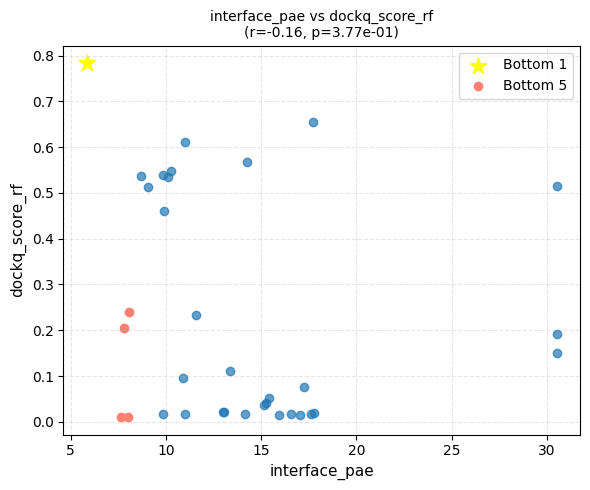

In [63]:
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/kkh/get_capri/combined_capri_rmsd.csv'
filter_pdb_id = '7yru_H_L_A'

df = pd.read_csv(csv_file)
if filter_pdb_id:
    df = df[df['pdb_id']==filter_pdb_id]

visualize_features(
    df=df,
    # x=['h1_rmsd', 'h2_rmsd', 'h3_rmsd', 'l1_rmsd', 'l2_rmsd', 'l3_rmsd'],
    # x=['h1_rmsd', 'h2_rmsd', 'h3_rmsd', 'l1_rmsd', 'l2_rmsd', 'l3_rmsd'],
    x='interface_pae',
    y='dockq_score_rf',
    merge_data=True,
    bottom_1=True,
    bottom_5=True,
    # subplot_shape=(2,3)
)

# visualize_features(
#     df=df,
#     x=['h1_rmsd', 'h2_rmsd', 'h3_rmsd', 'l1_rmsd', 'l2_rmsd', 'l3_rmsd'],
#     y='dockq_score_rf',
#     merge_data=True,
#     subplot_shape=(2,3)
# )

## 필터 기능 테스트 

### df merge (각 샘플들 중 h3 plddt 값이 가장 큰 샘플을 선택하고 rmsd는 평균값)

In [61]:
import pandas as pd 

csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/kkh/get_capri/combined_capri_rmsd.csv'
df = pd.read_csv(csv_file)
rmsd_cols = [c for c in df.columns if "rmsd" in c.lower()]
grouped = []
for (pdb_id, data_name), sub_df in df.groupby(['pdb_id', 'data_name']):
    max_plddt_row = sub_df.loc[sub_df['h3_plddt'].idxmax()].copy()
    for col in rmsd_cols:
        if col in sub_df.columns:
            max_plddt_row[col] = sub_df[col].mean()
    grouped.append(max_plddt_row)
df = pd.DataFrame(grouped).reset_index(drop=True)

### percentile (relative threshold)

In [ ]:
import pandas as pd
import numpy as np


def filter_and_compare_rel(df, metric, pct=20):
    """
    하나의 metric 기준으로 샘플을 filtering하고,
    interface_pae 기준 top1, top5 선택 전후를 비교
    
    Parameters:
        df (pd.DataFrame): 분석 데이터
        metric (str): filtering 기준 metric (예: 'h1_rmsd', 'h2_plddt')
        pct (float): filtering 비율 (RMSD 상위 pct 제거, pLDDT 하위 pct 제거)
    
    Returns:
        summary (dict): filtering 전후 top1/top5 dockq_score_rf, interface_pae 평균
        top1_before (pd.DataFrame): filtering 전 top1 샘플
        top5_before (pd.DataFrame): filtering 전 top5 샘플
        top1_after (pd.DataFrame): filtering 후 top1 샘플
        top5_after (pd.DataFrame): filtering 후 top5 샘플
    """
    
    # --- top1/top5 선택 함수 ---
    def get_top1_top5(df):
        top1_list = []
        top5_list = []
        for pdb_id, group in df.groupby('pdb_id'):
            if group.empty:
                continue
            top1 = group.loc[group['interface_pae'].idxmin()]
            candidates = group.nsmallest(5, 'interface_pae')
            top5 = candidates.loc[candidates['dockq_score_rf'].idxmax()]
            top1_list.append(top1)
            top5_list.append(top5)
        return pd.DataFrame(top1_list), pd.DataFrame(top5_list)
    
    # --- filtering 후 top1/top5 선택 함수 ---
    def analyze_metric_filtering(df, metric, pct):
        top1_list = []
        top5_list = []
        is_rmsd = 'rmsd' in metric.lower()
        
        for pdb_id, group in df.groupby('pdb_id'):
            if is_rmsd:
                cutoff = np.percentile(group[metric], 100 - pct)  # 상위 pct% 제거
                filtered = group[group[metric] <= cutoff]
            else:
                cutoff = np.percentile(group[metric], pct)  # 하위 pct% 제거
                filtered = group[group[metric] >= cutoff]
            
            if filtered.empty:
                continue
            
            top1 = filtered.loc[filtered['interface_pae'].idxmin()]
            top1_list.append(top1)
            
            candidates = filtered.nsmallest(5, 'interface_pae')
            top5 = candidates.loc[candidates['dockq_score_rf'].idxmax()]
            top5_list.append(top5)
        
        return pd.DataFrame(top1_list), pd.DataFrame(top5_list)
    
    # --- filtering 전 top1/top5 ---
    top1_before, top5_before = get_top1_top5(df)
    
    # --- filtering 후 top1/top5 ---
    top1_after, top5_after = analyze_metric_filtering(df, metric, pct)
    
    # --- summary 생성 ---
    summary = {
        'dockq_top1_before': top1_before['dockq_score_rf'].mean(),
        'dockq_top5_before': top5_before['dockq_score_rf'].mean(),
        'dockq_top1_after': top1_after['dockq_score_rf'].mean(),
        'dockq_top5_after': top5_after['dockq_score_rf'].mean(),
        'interface_pae_top1_before': top1_before['interface_pae'].mean(),
        'interface_pae_top5_before': top5_before['interface_pae'].mean(),
        'interface_pae_top1_after': top1_after['interface_pae'].mean(),
        'interface_pae_top5_after': top5_after['interface_pae'].mean(),
    }
    
    return summary, top1_before, top5_before, top1_after, top5_after


import matplotlib.pyplot as plt
import math

def plot_metric_vs_pct(df, metrics, pct_values):
    """
    각 metric별로 subplot으로 filtering pct 대비 dockq_top1_after, dockq_top5_after를 그림
    모든 subplot의 y축 범위와 틱을 통일
    
    Parameters:
        df (pd.DataFrame): 원본 데이터
        metrics (list): 분석할 metric 리스트
        pct_values (list): filtering pct 리스트
    """
    n_metrics = len(metrics)
    ncols = 3  # 한 줄에 subplot 3개
    nrows = math.ceil(n_metrics / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    axes = axes.flatten()
    
    # 모든 metric에서 dockq_top1_after/top5_after 값 수집하여 y축 범위 결정
    all_values = []
    for metric in metrics:
        for pct in pct_values:
            summary, _, _, _, _ = filter_and_compare_rel(df, metric, pct)
            all_values.append(summary['dockq_top1_after'])
            all_values.append(summary['dockq_top5_after'])
    
    y_min = min(all_values)
    y_max = max(all_values)
    
    for i, metric in enumerate(metrics):
        results_top1 = []
        results_top5 = []
        for pct in pct_values:
            summary, _, _, _, _ = filter_and_compare_rel(df, metric, pct)
            results_top1.append(summary['dockq_top1_after'])
            results_top5.append(summary['dockq_top5_after'])
        
        ax = axes[i]
        ax.plot(pct_values, results_top1, marker='o', label='top1')
        ax.plot(pct_values, results_top5, marker='s', label='top5')
        ax.set_title(metric)
        ax.set_xlabel('Filtering pct')
        ax.set_ylabel('dockq')
        ax.set_ylim(y_min-0.01, y_max+0.01)  # y축 통일
        ax.grid(True)
        ax.legend()
    
    # 남는 subplot 제거
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()



In [ ]:
###########################################################################
metrics = ['h1_rmsd','h2_rmsd','h3_rmsd','l1_rmsd','l2_rmsd','l3_rmsd',
           'h1_plddt','h2_plddt','h3_plddt','l1_plddt','l2_plddt','l3_plddt']
pct_values = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
###########################################################################
plot_metric_vs_pct(df, metrics, pct_values)

## absolute threshold 

In [ ]:
import pandas as pd
import numpy as np



def filter_and_compare_absolute(df, metric, cutoff_list):
    """
    절댓값 cutoff 기준으로 샘플을 filtering하고,
    interface_pae 기준 top1, top5 선택 전후를 비교

    Parameters:
        df (pd.DataFrame): 분석 데이터
        metric (str): filtering 기준 metric (예: 'h1_rmsd', 'h2_plddt')
        cutoff_list (list): 절댓값 cutoff 리스트

    Returns:
        result_dict (dict): 각 cutoff별 summary와 top1/top5 DataFrame
    """
    
    # --- top1/top5 선택 함수 ---
    def get_top1_top5(group):
        if group.empty:
            return None, None
        top1 = group.loc[group['interface_pae'].idxmin()]
        candidates = group.nsmallest(5, 'interface_pae')
        top5 = candidates.loc[candidates['dockq_score_rf'].idxmax()]
        return top1, top5
    
    result_dict = {}
    is_rmsd = 'rmsd' in metric.lower()
    
    for cutoff in cutoff_list:
        top1_list_before = []
        top5_list_before = []
        top1_list_after = []
        top5_list_after = []

        for pdb_id, group in df.groupby('pdb_id'):
            # --- filtering 전 top1/top5 ---
            t1_before, t5_before = get_top1_top5(group)
            if t1_before is not None:
                top1_list_before.append(t1_before)
            if t5_before is not None:
                top5_list_before.append(t5_before)

            # --- filtering 후 ---
            if is_rmsd:
                filtered = group[group[metric] <= cutoff]
                # 샘플 수 5개 미만이면 RMSD 기준 상위 5개 선택
                if len(filtered) < 5:
                    filtered = group.nsmallest(5, metric)
            else:
                filtered = group[group[metric] >= cutoff]
                # 샘플 수 5개 미만이면 pLDDT 기준 상위 5개 선택
                if len(filtered) < 5:
                    filtered = group.nlargest(5, metric)
            
            t1_after, t5_after = get_top1_top5(filtered)
            if t1_after is not None:
                top1_list_after.append(t1_after)
            if t5_after is not None:
                top5_list_after.append(t5_after)
        
        # DataFrame 변환
        top1_before_df = pd.DataFrame(top1_list_before)
        top5_before_df = pd.DataFrame(top5_list_before)
        top1_after_df = pd.DataFrame(top1_list_after)
        top5_after_df = pd.DataFrame(top5_list_after)
        
        # summary 생성
        summary = {
            'dockq_top1_before': top1_before_df['dockq_score_rf'].mean(),
            'dockq_top5_before': top5_before_df['dockq_score_rf'].mean(),
            'dockq_top1_after': top1_after_df['dockq_score_rf'].mean(),
            'dockq_top5_after': top5_after_df['dockq_score_rf'].mean(),
            'interface_pae_top1_before': top1_before_df['interface_pae'].mean(),
            'interface_pae_top5_before': top5_before_df['interface_pae'].mean(),
            'interface_pae_top1_after': top1_after_df['interface_pae'].mean(),
            'interface_pae_top5_after': top5_after_df['interface_pae'].mean(),
        }

        result_dict[cutoff] = {
            'summary': summary,
            'top1_before': top1_before_df,
            'top5_before': top5_before_df,
            'top1_after': top1_after_df,
            'top5_after': top5_after_df
        }
    
    return result_dict

import matplotlib.pyplot as plt

def plot_multiple_metrics(result_dicts, metrics, value='dockq_score_rf', subplot_shape=(4,3)):
    """
    여러 metric에 대해 top1/top5 cutoff plot을 subplot으로 한 번에 그림.
    x축은 cutoff 리스트 순서 그대로 표시하며, 간격은 동일.
    모든 subplot의 y축 범위를 통일.

    Parameters
    ----------
    result_dicts : dict
        {metric_name: result_dict} 형태, filter_and_compare_absolute 반환값
    metrics : list
        subplot으로 그릴 metric 리스트
    value : str, optional
        시각화할 컬럼 ('dockq_score_rf' 또는 'interface_pae')
    subplot_shape : tuple(int,int), optional
        subplot 행, 열
    """
    nrows, ncols = subplot_shape
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    axes = axes.flatten()

    # 전체 y축 범위 계산
    all_values = []
    for metric in metrics:
        result_dict = result_dicts[metric]
        for c in result_dict.keys():
            all_values.append(result_dict[c]['top1_after'][value].mean())
            all_values.append(result_dict[c]['top5_after'][value].mean())
    y_min = min(all_values)
    y_max = max(all_values)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        result_dict = result_dicts[metric]
        cutoffs = list(result_dict.keys())  # 순서 유지

        top1_means = [result_dict[c]['top1_after'][value].mean() for c in cutoffs]
        top5_means = [result_dict[c]['top5_after'][value].mean() for c in cutoffs]
        
        # x축은 동일 간격, cutoff 순서대로 표시
        x = range(len(cutoffs))
        ax.plot(x, top1_means, marker='o', label='top1')
        ax.plot(x, top5_means, marker='s', label='top5')
        ax.set_xticks(x)
        ax.set_xticklabels([str(c) for c in cutoffs])
        
        ax.set_xlabel(f'{metric} cutoff')
        ax.set_ylabel('dockq')
        ax.set_title(metric)
        ax.set_ylim(y_min-0.01, y_max+0.01)  # y축 통일
        ax.grid(True)
        ax.legend()

    # 남는 subplot 제거
    for j in range(len(metrics), nrows*ncols):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()




In [ ]:
###########################################################################
# metric 목록 예시
metrics = ['h1_rmsd','h2_rmsd','h3_rmsd','l1_rmsd','l2_rmsd','l3_rmsd',
           'h1_plddt','h2_plddt','h3_plddt','l1_plddt','l2_plddt','l3_plddt']

# cutoff 리스트
rmsd_cutoffs = [15, 6, 5, 4, 3, 2, 1, 0.5]
plddt_cutoffs = [0, 60, 65, 70, 75, 80, 85, 90]

# 모든 metric 처리
result_dicts = {}
for metric in metrics:
    if 'rmsd' in metric.lower():
        result_dicts[metric] = filter_and_compare_absolute(df, metric, rmsd_cutoffs)
    else:
        result_dicts[metric] = filter_and_compare_absolute(df, metric, plddt_cutoffs)

# subplot 12개로 top1/top5 plot
plot_multiple_metrics(result_dicts, metrics, value='dockq_score_rf', subplot_shape=(4,3))
###########################################################################

## capri 개수를 기준으로 

In [62]:
import pandas as pd
import numpy as np

def filter_and_compare_rel_multi(df, metrics_with_pct):
    """
    여러 (metric, pct) 조건을 동시에 적용해 filtering 후,
    interface_pae 기준으로 top1, top5 선택 전후를 비교
    
    Parameters:
        df (pd.DataFrame): 분석 데이터
        metrics_with_pct (list of tuple): [(metric명, pct), ...]
            예: [('h1_rmsd', 20), ('h2_plddt', 10)]
            RMSD류는 상위 pct% 제거, pLDDT류는 하위 pct% 제거
    
    Returns:
        summary (dict)
        top1_before, top5_before, top1_after, top5_after (pd.DataFrame)
    """

    # --- top1/top5 선택 함수 ---
    def get_top1_top5(df):
        top1_list = []
        top5_list = []
        for pdb_id, group in df.groupby('pdb_id'):
            if group.empty:
                continue
            top1 = group.loc[group['interface_pae'].idxmin()]
            candidates = group.nsmallest(5, 'interface_pae')
            top5 = candidates.loc[candidates['dockq_score_rf'].idxmax()]
            top1_list.append(top1)
            top5_list.append(top5)
        return pd.DataFrame(top1_list), pd.DataFrame(top5_list)
    
    def apply_multi_filter(df, metrics_with_pct):
        """
        각 pdb_id 그룹 내에서 여러 (metric, pct) 조건을 동시에 적용하여 필터링
        
        모든 조건을 만족하는 행만 남김 (AND 조건)
        """
        if df.empty:
            return df
        
        filtered_groups = []

        for pdb_id, group in df.groupby('pdb_id'):
            if group.empty:
                continue

            mask = np.ones(len(group), dtype=bool)  # 초기 전체 True mask

            for metric, pct in metrics_with_pct:
                if metric not in group.columns:
                    continue

                is_rmsd = 'rmsd' in metric.lower()

                # 각 metric에 대해 cutoff 계산 (pdb_id별)
                if is_rmsd:
                    cutoff = np.percentile(group[metric], 100 - pct)
                    mask &= group[metric] <= cutoff
                else:
                    cutoff = np.percentile(group[metric], pct)
                    mask &= group[metric] >= cutoff

            filtered_groups.append(group[mask])

        # 그룹별 필터링 결과 합치기
        return pd.concat(filtered_groups, ignore_index=True)


    # --- filtering 전 ---
    top1_before, top5_before = get_top1_top5(df)
    
    # --- filtering 후 ---
    filtered_df = apply_multi_filter(df, metrics_with_pct)
    top1_after, top5_after = get_top1_top5(filtered_df)
    
    # --- summary 생성 ---
    summary = {
        'dockq_top1_before': top1_before['dockq_score_rf'].mean(),
        'dockq_top5_before': top5_before['dockq_score_rf'].mean(),
        'dockq_top1_after': top1_after['dockq_score_rf'].mean(),
        'dockq_top5_after': top5_after['dockq_score_rf'].mean(),
        'interface_pae_top1_before': top1_before['interface_pae'].mean(),
        'interface_pae_top5_before': top5_before['interface_pae'].mean(),
        'interface_pae_top1_after': top1_after['interface_pae'].mean(),
        'interface_pae_top5_after': top5_after['interface_pae'].mean(),
        'n_before': len(df),
        'n_after': len(filtered_df)
    }

    return summary, top1_before, top5_before, top1_after, top5_after

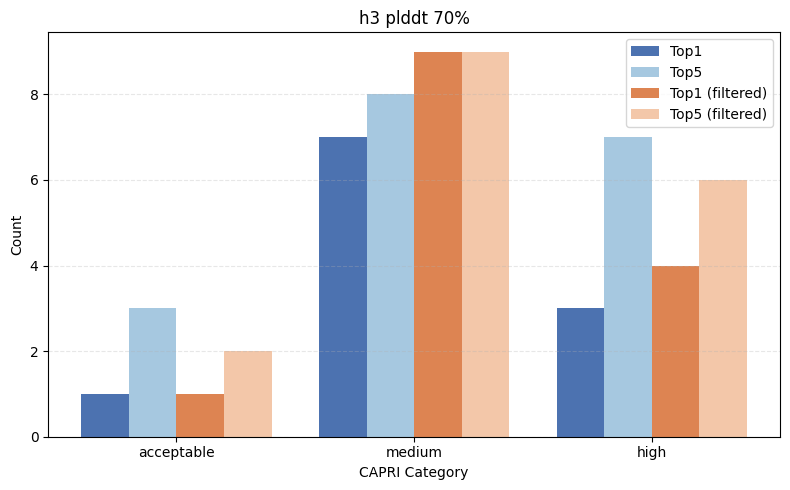

In [78]:
title = 'h3 plddt 70%'
summary, top1_before, top5_before, top1_after, top5_after = filter_and_compare_rel_multi(df, [('h3_plddt', 70)])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_capri_category_counts(top1_before, top5_before, top1_after, top5_after):
    """
    capri_rf 범주별로 top1, top5, top1_filter, top5_filter의 개수를 비교하는 막대그래프
    
    Parameters
    ----------
    top1_before, top5_before, top1_after, top5_after : pd.DataFrame
        각각 filter 전/후의 top1, top5 데이터
    """
    
    categories = ['acceptable', 'medium', 'high']
    bar_width = 0.2
    x = np.arange(len(categories))
    
    # 각 데이터프레임에서 capri_rf별 개수 계산
    count_top1_before = top1_before['capri_rf'].value_counts().reindex(categories, fill_value=0)
    count_top5_before = top5_before['capri_rf'].value_counts().reindex(categories, fill_value=0)
    count_top1_after = top1_after['capri_rf'].value_counts().reindex(categories, fill_value=0)
    count_top5_after = top5_after['capri_rf'].value_counts().reindex(categories, fill_value=0)
    
    # 색상 팔레트 설정 (Top1/Top5는 진한색, filtered는 같은 계열의 연한색)
    colors = {
        'top1_before': '#4C72B0',   # 진한 파랑
        'top5_before': '#A6C8E0',   # 진한 주황
        'top1_after':  '#DD8452',   # 연파랑
        'top5_after':  '#F3C7A9'    # 연주황
    }
    
    plt.figure(figsize=(8, 5))
    
    # 막대 순서: Top1 → Top5 → Top1(filtered) → Top5(filtered)
    plt.bar(x - 1.5*bar_width, count_top1_before, width=bar_width, color=colors['top1_before'], label='Top1')
    plt.bar(x - 0.5*bar_width, count_top5_before, width=bar_width, color=colors['top5_before'], label='Top5')
    plt.bar(x + 0.5*bar_width, count_top1_after,  width=bar_width, color=colors['top1_after'],  label='Top1 (filtered)')
    plt.bar(x + 1.5*bar_width, count_top5_after,  width=bar_width, color=colors['top5_after'],  label='Top5 (filtered)')
    
    # 그래프 꾸미기
    plt.xticks(x, categories)
    plt.ylabel("Count")
    plt.xlabel("CAPRI Category")
    plt.title(title)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


plot_capri_category_counts(top1_before, top5_before, top1_after, top5_after)

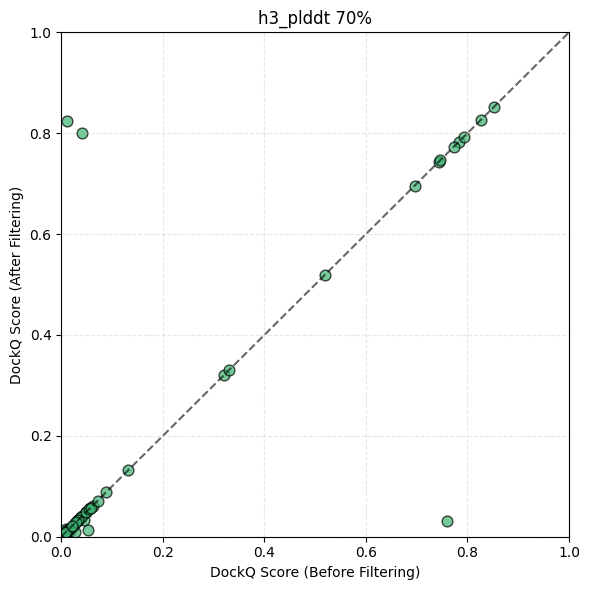

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

def scatter_dockq_before_after(top1_before, top1_after):
    """
    top1_before['dockq_score_rf']와 top1_after['dockq_score_rf'] 간의 scatter plot
    
    Parameters
    ----------
    top1_before : pd.DataFrame
        필터 전 top1 데이터
    top1_after : pd.DataFrame
        필터 후 top1 데이터
    """
    
    # 공통 pdb_id 기준 병합
    merged = pd.merge(
        top1_before[['pdb_id', 'dockq_score_rf']],
        top1_after[['pdb_id', 'dockq_score_rf']],
        on='pdb_id',
        how='inner',
        suffixes=('_before', '_after')
    )
    
    # 산점도
    plt.figure(figsize=(6, 6))
    plt.scatter(
        merged['dockq_score_rf_before'],
        merged['dockq_score_rf_after'],
        alpha=0.7,
        s=60,
        c='mediumseagreen',
        edgecolor='k'
    )
    
    # 대각선 (y = x)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    
    # 축 설정
    plt.xlabel('DockQ Score (Before Filtering)')
    plt.ylabel('DockQ Score (After Filtering)')
    plt.title(f"{metric} {pct}%")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
scatter_dockq_before_after(top1_before, top1_after)